# START HERE: Enter This Week's Percentages

Edit the next code cell with your current week's activity percentages. The values should represent the share of all tracked time. If they do not add up to exactly 100, the notebook will normalize them.

In [16]:
CURRENT_RECORD_MODE = "percent"

# EDIT THESE VALUES ONLY
current_week_record_percentages = {
    "Sleeping": 25.15,
    "Studying/ Homework": 17.71,
    "Attending classes and labs": 2.98,
    "Cooking or eating": 2.98,
    "Grooming": 2.38,
    "Gaming": 9.97,
    "Working": 6.10,
    "Relaxing / PC / mobile": 26.04,
    "Learning": 0.45,
    "Meetings": 0.89,
    "Exercises": 0.60,
    "Books": 0.89,
    "Transportation": 2.08,
    "Others": 1.79,
}


# Next-Week Performance Forecasting from This Week's Routine

This notebook turns the Excel workbook into a clean weekly time-series dataset, trains a compact forecasting model on your 2024 and 2025 routine history, and predicts next week's performance from this week's activity record.

The project is intentionally self-contained: it uses `pandas`, `numpy`, `matplotlib`, and Python's standard library to read the `.xlsx` file. The main prediction flow is: enter this week's routine percentages at the top, train on your historical workbook data, and forecast next week's performance.

## Project Framing

The Excel workbook stores weekly percentages for routine categories such as sleeping, studying, classes, gaming, work, books, and transportation. The model learns the transition from week `t` to week `t + 1`, then uses the current-week percentages you entered at the top as the forecasting signal.

The notebook predicts:

- next-week Routine Performance Score from this week's activity record
- next-week percentage allocation for every activity category
- a transparent score derived from study, learning, work, books, exercise, sleep balance, and leisure load
- practical forecast notes that highlight focus risk, screen-time pressure, and the largest expected changes

Because the workbook now includes two years of personal history, the forecast has more context than the earlier single-year version. It is still best treated as a decision-support model rather than a certainty engine.

In [17]:
from pathlib import Path
from zipfile import ZipFile
import re
import warnings
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 10,
})

## 1. Load the Raw Excel Workbook

The source workbook has separate sheets for each year. The loader below reads the `.xlsx` file directly, so the notebook can use both years without requiring an extra Excel dependency such as `openpyxl`.

In [18]:
EXCEL_CANDIDATES = [
    Path("yearly record.xlsx"),
    Path("yearly_record.xlsx"),
]

EXCEL_FILE = next((path for path in EXCEL_CANDIDATES if path.exists()), None)

if EXCEL_FILE is None:
    available_workbooks = "\n".join(str(path) for path in Path(".").glob("*.xlsx"))
    raise FileNotFoundError(
        "Could not find the routine Excel workbook. Expected one of: "
        + ", ".join(str(path) for path in EXCEL_CANDIDATES)
        + f"\n\nExcel files in this folder:\n{available_workbooks}"
    )

XLSX_NS = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"
REL_NS = "{http://schemas.openxmlformats.org/officeDocument/2006/relationships}"


def column_name_to_index(cell_reference):
    match = re.match(r"[A-Z]+", str(cell_reference))
    if not match:
        return 0

    index = 0
    for letter in match.group(0):
        index = index * 26 + ord(letter) - ord("A") + 1
    return index - 1


def read_shared_strings(archive):
    if "xl/sharedStrings.xml" not in archive.namelist():
        return []

    root = ET.fromstring(archive.read("xl/sharedStrings.xml"))
    shared_strings = []

    for item in root.findall(f"{XLSX_NS}si"):
        text_parts = [node.text or "" for node in item.findall(f".//{XLSX_NS}t")]
        shared_strings.append("".join(text_parts))

    return shared_strings


def read_cell_value(cell, shared_strings):
    data_type = cell.attrib.get("t")

    if data_type == "s":
        value_node = cell.find(f"{XLSX_NS}v")
        if value_node is None or value_node.text is None:
            return ""
        return shared_strings[int(value_node.text)]

    if data_type == "inlineStr":
        return "".join(node.text or "" for node in cell.findall(f".//{XLSX_NS}t"))

    value_node = cell.find(f"{XLSX_NS}v")
    return value_node.text if value_node is not None and value_node.text is not None else ""


def read_xlsx_workbook(path):
    sheets = {}

    with ZipFile(path) as archive:
        shared_strings = read_shared_strings(archive)
        workbook = ET.fromstring(archive.read("xl/workbook.xml"))
        relationships = ET.fromstring(archive.read("xl/_rels/workbook.xml.rels"))
        relationship_targets = {rel.attrib["Id"]: rel.attrib["Target"] for rel in relationships}

        for sheet in workbook.findall(f"{XLSX_NS}sheets/{XLSX_NS}sheet"):
            sheet_name = sheet.attrib["name"]
            relationship_id = sheet.attrib[f"{REL_NS}id"]
            target = relationship_targets[relationship_id].lstrip("/")
            worksheet_path = target if target.startswith("xl/") else f"xl/{target}"

            worksheet = ET.fromstring(archive.read(worksheet_path))
            rows = []
            max_columns = 0

            for row in worksheet.findall(f"{XLSX_NS}sheetData/{XLSX_NS}row"):
                values = []

                for cell in row.findall(f"{XLSX_NS}c"):
                    column_index = column_name_to_index(cell.attrib.get("r", "A1"))
                    while len(values) <= column_index:
                        values.append("")
                    values[column_index] = read_cell_value(cell, shared_strings)

                max_columns = max(max_columns, len(values))
                rows.append(values)

            padded_rows = [row + [""] * (max_columns - len(row)) for row in rows]
            sheets[sheet_name] = pd.DataFrame(padded_rows, dtype=str)

    return sheets


print(f"Using Excel workbook: {EXCEL_FILE.resolve()}")
raw_sheets = read_xlsx_workbook(EXCEL_FILE)

sheet_summary = pd.DataFrame(
    [
        {"sheet": name, "rows": sheet.shape[0], "columns": sheet.shape[1]}
        for name, sheet in raw_sheets.items()
    ]
)

display(sheet_summary)
first_sheet_name = next(iter(raw_sheets))
raw_sheets[first_sheet_name].head(8)

Using Excel workbook: D:\model training with personal data\personal-routine-ml\yearly record.xlsx


,sheet,rows,columns
0,2024,973,67
1,2025,973,53


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66
0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2,2024,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4,,"8th semester FAll 2024 (cse471, cse260, cse423...",,,,,,,,,,,,,"7th semester summer 2024 (CSE370, CSE331, CSE2...",,,,,,,,,,,,,,,,,,,,,"6th semester spring 2024 (CSE221, CSE250, CSE3...",,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5,9451,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
6,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
7,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


## 2. Parse the Weekly Activity Tables

Each yearly sheet is arranged like a spreadsheet export: activities are rows and weeks are columns. This step extracts each year's activity table, converts Excel decimal percentages into normal percentages, combines all years, and sorts the records chronologically.

In [19]:
ACTIVITY_RENAMES = {
    "Coooking or eating": "Cooking or eating",
    "Relaxing/ pc/ mobile": "Relaxing / PC / mobile",
    "Transportation": "Transportation",
    "Sleeping": "Sleeping",
    "Studying/ Homework": "Studying/ Homework",
    "Attending classes and labs": "Attending classes and labs",
    "Grooming": "Grooming",
    "Gaming": "Gaming",
    "Working": "Working",
    "Learning": "Learning",
    "Meetings": "Meetings",
    "Exercises": "Exercises",
    "Books": "Books",
    "Others": "Others",
}


def normalize_activity_name(name):
    cleaned = re.sub(r"\s+", " ", str(name)).strip()
    return ACTIVITY_RENAMES.get(cleaned, cleaned)


def infer_sheet_year(sheet_name):
    match = re.search(r"(20\d{2})", str(sheet_name))
    return int(match.group(1)) if match else None


def extract_week_num(label):
    text = str(label).strip().lower()
    if not any(token in text for token in ["week", "weel", "wek"]):
        return None
    match = re.search(r"(\d{1,2})", text)
    return int(match.group(1)) if match else None


def parse_percent(value):
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none", "-", "x"}:
        return np.nan

    has_percent_sign = "%" in text
    text = text.replace("%", "").replace(",", "")

    try:
        number = float(text)
    except ValueError:
        return np.nan

    if has_percent_sign:
        return number

    if 0 <= abs(number) <= 1:
        return number * 100

    return number


def build_weekly_activity_table(raw_sheet, source_sheet, year):
    first_col = raw_sheet.iloc[:, 0].astype(str).str.strip().str.lower()
    header_matches = first_col[first_col.str.contains("activit", regex=False)]

    if header_matches.empty:
        raise ValueError(f"Could not find the activity header row in sheet {source_sheet}.")

    header_row = int(header_matches.index[0])
    header_values = raw_sheet.iloc[header_row].tolist()

    week_columns = []
    for col_idx, label in enumerate(header_values):
        week_num = extract_week_num(label)
        if week_num is not None:
            period_label = f"{year}-W{week_num:02d}"
            week_columns.append((week_num, col_idx, str(label).strip(), period_label))

    if not week_columns:
        raise ValueError(f"Could not find week columns in sheet {source_sheet}.")

    records = []
    activity_order = []

    for _, row in raw_sheet.iloc[header_row + 1 :].iterrows():
        activity = normalize_activity_name(row.iloc[0])

        if not activity:
            continue
        if activity.lower() == "total":
            break
        if activity not in activity_order:
            activity_order.append(activity)

        for week_num, col_idx, week_label, period_label in week_columns:
            records.append(
                {
                    "year": year,
                    "week_num": week_num,
                    "period_label": period_label,
                    "week_label": week_label,
                    "source_sheet": source_sheet,
                    "activity": activity,
                    "percent": parse_percent(row.iloc[col_idx]),
                }
            )

    long_df = pd.DataFrame(records)
    weekly_df = (
        long_df.pivot_table(
            index=["year", "week_num", "period_label", "source_sheet"],
            columns="activity",
            values="percent",
            aggfunc="first",
        )
        .reset_index()
        .sort_values(["year", "week_num"])
    )

    weekly_df = weekly_df.reindex(columns=["year", "week_num", "period_label", "source_sheet"] + activity_order)
    weekly_df[activity_order] = weekly_df[activity_order].apply(pd.to_numeric, errors="coerce")
    weekly_df = weekly_df.dropna(subset=activity_order, how="all")
    weekly_df[activity_order] = weekly_df[activity_order].fillna(0.0)
    weekly_df["observed_total"] = weekly_df[activity_order].sum(axis=1)

    return weekly_df, long_df, activity_order


def build_combined_weekly_activity_table(raw_workbook_sheets):
    weekly_tables = []
    long_tables = []
    combined_activity_order = []

    for sheet_name, raw_sheet in raw_workbook_sheets.items():
        year = infer_sheet_year(sheet_name)
        if year is None:
            print(f"Skipping sheet without a year in its name: {sheet_name}")
            continue

        sheet_weekly, sheet_long, sheet_activity_order = build_weekly_activity_table(raw_sheet, sheet_name, year)
        if sheet_weekly.empty:
            print(f"Skipping sheet with no usable weekly data: {sheet_name}")
            continue

        weekly_tables.append(sheet_weekly)
        long_tables.append(sheet_long)

        for activity in sheet_activity_order:
            if activity not in combined_activity_order:
                combined_activity_order.append(activity)

    if not weekly_tables:
        raise ValueError("No usable weekly activity tables were found in the workbook.")

    weekly_df = pd.concat(weekly_tables, ignore_index=True, sort=False)

    for activity in combined_activity_order:
        if activity not in weekly_df.columns:
            weekly_df[activity] = 0.0

    weekly_df[combined_activity_order] = weekly_df[combined_activity_order].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    weekly_df = weekly_df.sort_values(["year", "week_num"]).reset_index(drop=True)
    weekly_df["observed_total"] = weekly_df[combined_activity_order].sum(axis=1)
    weekly_df.index.name = "record_id"

    long_df = pd.concat(long_tables, ignore_index=True, sort=False)
    return weekly_df, long_df, combined_activity_order


weekly, long_data, activity_cols = build_combined_weekly_activity_table(raw_sheets)

preview_cols = ["period_label"] + activity_cols

display(weekly[preview_cols].head().round(2))
display(weekly[preview_cols].tail().round(2))
print(f"Parsed {len(weekly)} weekly observations and {len(activity_cols)} activity categories.")
print(f"Years included: {', '.join(map(str, sorted(weekly['year'].unique())))}")
print(f"Period range: {weekly['period_label'].iloc[0]} to {weekly['period_label'].iloc[-1]}")

activity,period_label,Sleeping,Studying/ Homework,Attending classes and labs,Cooking or eating,Grooming,Gaming,Working,Relaxing / PC / mobile,Learning,Meetings,Exercises,Books,Transportation,Others
record_id,,,,,,,,,,,,,,,
0,2024-W02,25.21,2.71,0.00,4.79,3.12,14.79,5.62,18.54,3.12,2.50,0.62,6.67,3.33,8.96
1,2024-W03,26.34,0.00,0.00,3.12,2.08,11.31,16.22,22.92,2.23,2.23,0.00,5.80,0.60,7.14
2,2024-W04,25.45,4.02,6.85,2.83,2.23,4.46,14.73,19.35,1.49,0.74,0.30,5.21,3.87,8.48
3,2024-W05,23.96,11.16,8.04,2.53,3.27,1.93,12.20,15.92,1.64,1.04,2.53,6.25,3.12,6.40
4,2024-W06,23.51,13.10,7.59,4.17,2.68,0.15,13.99,15.92,5.21,0.60,1.49,5.51,2.68,3.42


activity,period_label,Sleeping,Studying/ Homework,Attending classes and labs,Cooking or eating,Grooming,Gaming,Working,Relaxing / PC / mobile,Learning,Meetings,Exercises,Books,Transportation,Others
record_id,,,,,,,,,,,,,,,
80,2025-W43,24.70,5.51,8.63,3.87,2.53,2.38,4.32,31.70,3.12,3.42,1.34,1.19,3.42,3.87
81,2025-W44,28.72,8.33,8.78,3.72,2.23,3.42,6.55,27.08,0.74,1.04,1.93,0.00,3.72,3.72
82,2025-W45,24.38,7.29,10.62,4.17,2.71,1.88,5.83,27.08,0.62,4.58,1.88,0.00,5.21,3.75
83,2025-W46,25.21,10.42,7.08,3.75,1.88,7.50,3.96,24.58,3.75,4.58,1.04,0.00,2.08,4.17
84,2025-W47,27.78,1.74,9.03,4.17,2.08,6.60,3.12,32.99,2.43,2.08,2.08,0.00,3.47,2.43


Parsed 85 weekly observations and 14 activity categories.
Years included: 2024, 2025
Period range: 2024-W02 to 2025-W47


## 3. Data Quality and Routine Profile

Before training, check whether the weekly percentages sum close to 100 and inspect the average time allocation across all workbook years.

,metric,value
0,number_of_weeks,85
1,years_included,"2024, 2025"
2,first_period,2024-W02
3,last_period,2025-W47
4,activity_categories,14
5,mean_weekly_total,100.00
6,max_total_error,0.01


,mean,std,min,max
activity,,,,
Sleeping,25.40,2.39,20.57,33.68
Relaxing / PC / mobile,22.00,4.58,13.54,33.33
Gaming,9.61,5.16,0.00,26.39
Working,8.11,3.87,0.69,17.86
Studying/ Homework,6.33,4.29,0.00,16.22
Attending classes and labs,4.67,3.12,0.00,10.62
Cooking or eating,3.78,0.56,2.53,5.42
Others,3.77,1.91,1.04,12.50
Meetings,3.56,1.93,0.60,9.90


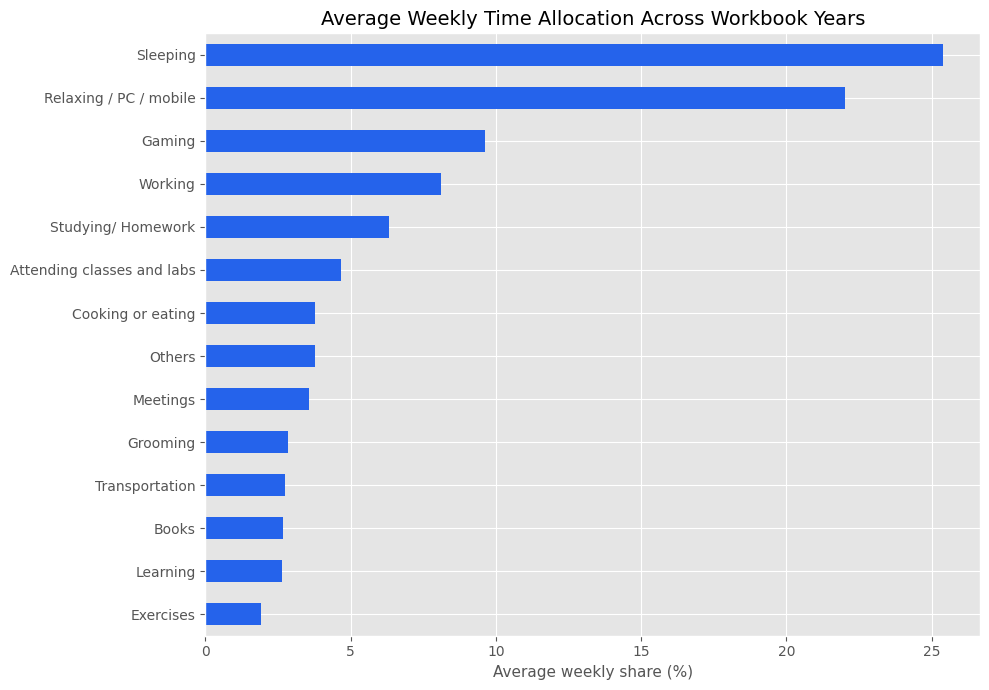

In [20]:
quality_summary = pd.DataFrame(
    {
        "metric": [
            "number_of_weeks",
            "years_included",
            "first_period",
            "last_period",
            "activity_categories",
            "mean_weekly_total",
            "max_total_error",
        ],
        "value": [
            len(weekly),
            ", ".join(map(str, sorted(weekly["year"].unique()))),
            weekly["period_label"].iloc[0],
            weekly["period_label"].iloc[-1],
            len(activity_cols),
            weekly["observed_total"].mean(),
            (weekly["observed_total"] - 100).abs().max(),
        ],
    }
)

display(quality_summary)

activity_summary = (
    weekly[activity_cols]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .sort_values("mean", ascending=False)
)

display(activity_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 7))
activity_summary["mean"].sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Average Weekly Time Allocation Across Workbook Years")
ax.set_xlabel("Average weekly share (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Performance Score

The workbook does not contain a single success label, so the notebook builds a transparent score from the routine itself. The score is editable: adjust the weights if your definition of a strong week changes.

In [21]:
IDEAL_SLEEP_PERCENT = 33.3

ACADEMIC_COLS = ["Studying/ Homework", "Attending classes and labs", "Learning", "Books"]
WORK_COLS = ["Working", "Meetings"]
LEISURE_COLS = ["Gaming", "Relaxing / PC / mobile"]
SELF_CARE_COLS = ["Sleeping", "Cooking or eating", "Grooming", "Exercises"]


def safe_sum(frame, columns):
    existing = [col for col in columns if col in frame.columns]
    if not existing:
        return pd.Series(0.0, index=frame.index)
    return frame[existing].sum(axis=1)


def add_behavior_features(frame):
    out = frame.copy()
    if "week_num" in out.columns:
        week_numbers = pd.Series(out["week_num"].astype(float).to_numpy(), index=out.index)
    else:
        week_numbers = pd.Series(pd.Index(out.index).astype(float), index=out.index)

    out["academic_focus"] = safe_sum(out, ACADEMIC_COLS)
    out["productive_time"] = out["academic_focus"] + safe_sum(out, WORK_COLS)
    out["screen_leisure"] = safe_sum(out, LEISURE_COLS)
    out["self_care"] = safe_sum(out, SELF_CARE_COLS)
    out["sleep_gap_from_ideal"] = (out["Sleeping"] - IDEAL_SLEEP_PERCENT).abs()
    out["week_progress"] = week_numbers / 53.0
    out["week_sin"] = np.sin(2 * np.pi * week_numbers / 52.0)
    out["week_cos"] = np.cos(2 * np.pi * week_numbers / 52.0)

    return out


def routine_performance_score(frame):
    academic = safe_sum(frame, ACADEMIC_COLS)
    work = safe_sum(frame, ["Working"])
    meetings = safe_sum(frame, ["Meetings"])
    exercise = safe_sum(frame, ["Exercises"])
    leisure = safe_sum(frame, LEISURE_COLS)
    sleep_gap = (frame["Sleeping"] - IDEAL_SLEEP_PERCENT).abs()

    raw_score = (
        2.20 * academic
        + 1.00 * work
        + 0.55 * meetings
        + 1.20 * exercise
        - 0.85 * leisure
        - 1.10 * sleep_gap
    )

    low, high = raw_score.min(), raw_score.max()
    if np.isclose(high, low):
        return pd.Series(50.0, index=frame.index, name="performance_score")

    normalized = 100 * (raw_score - low) / (high - low)
    return normalized.clip(0, 100).rename("performance_score")


weekly_features = add_behavior_features(weekly[activity_cols + ["year", "week_num"]])
weekly_model = weekly_features.copy()
weekly_model["period_label"] = weekly["period_label"]
weekly_model["source_sheet"] = weekly["source_sheet"]
weekly_model["performance_score"] = routine_performance_score(weekly_features)

derived_cols = [
    "academic_focus",
    "productive_time",
    "screen_leisure",
    "self_care",
    "sleep_gap_from_ideal",
    "performance_score",
]

display(pd.concat([weekly_model[["period_label"]], weekly_model[derived_cols]], axis=1).tail(10).round(2))

activity,period_label,academic_focus,productive_time,screen_leisure,self_care,sleep_gap_from_ideal,performance_score
record_id,,,,,,,
75,2025-W26,12.15,25.69,32.47,34.38,10.38,39.16
76,2025-W27,17.53,30.21,26.91,38.19,6.91,62.18
77,2025-W40,5.38,18.75,41.15,35.59,4.31,17.14
78,2025-W41,12.65,26.34,33.18,34.52,7.11,40.92
79,2025-W42,8.63,20.54,34.82,36.76,5.17,29.45
80,2025-W43,18.45,26.19,34.08,32.44,8.60,45.67
81,2025-W44,17.86,25.45,30.51,36.61,4.58,54.00
82,2025-W45,18.54,28.96,28.96,33.12,8.92,53.15
83,2025-W46,21.25,29.79,32.08,31.88,8.09,54.59


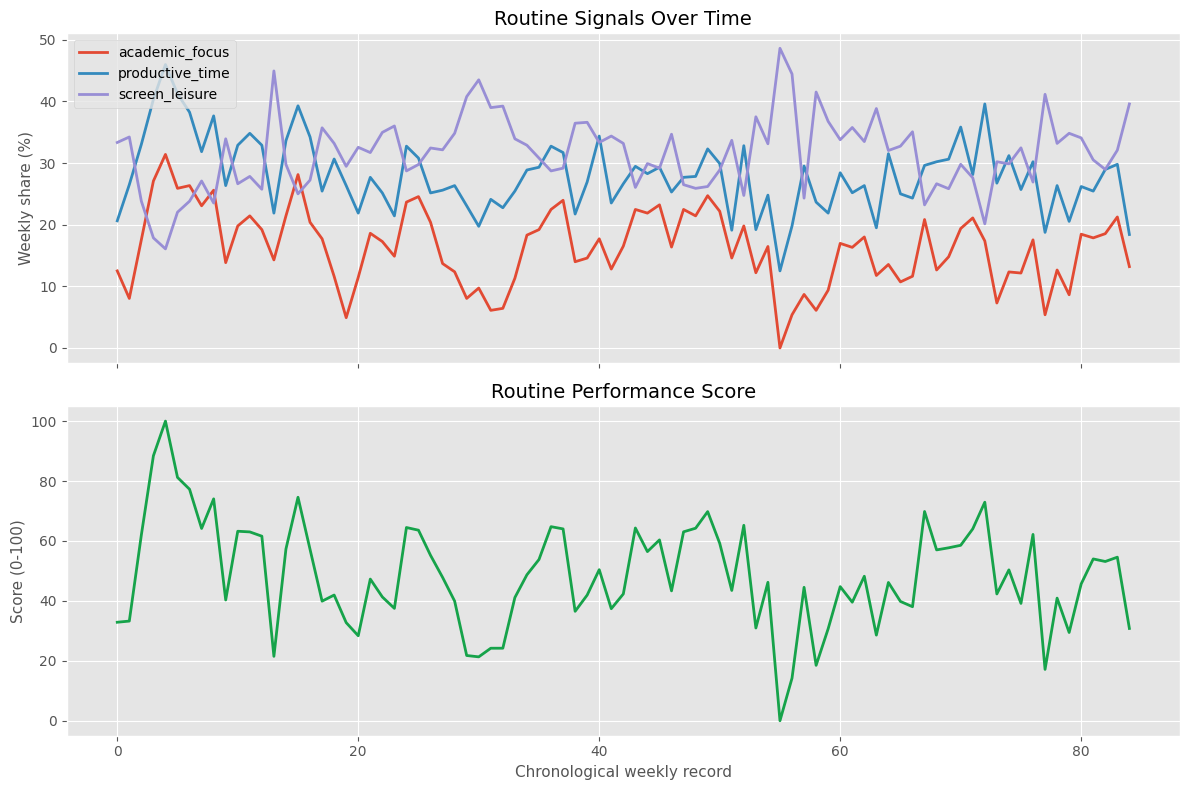

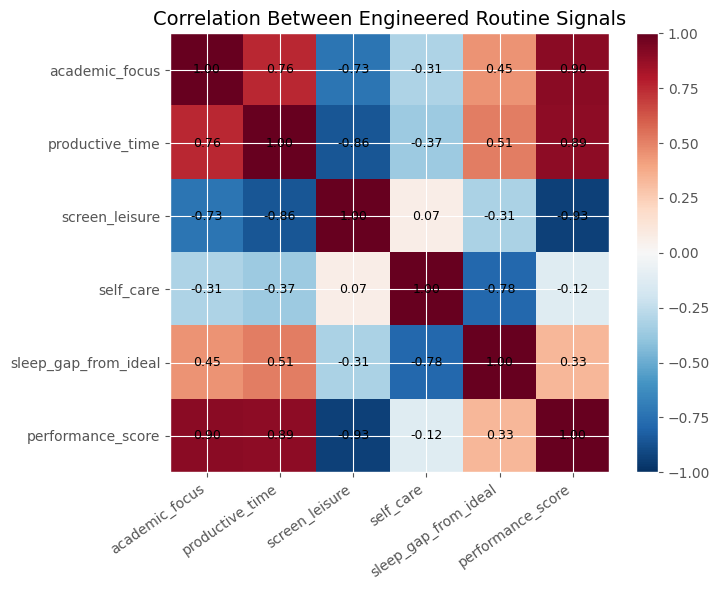

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

weekly_model[["academic_focus", "productive_time", "screen_leisure"]].plot(ax=axes[0], linewidth=2)
axes[0].set_title("Routine Signals Over Time")
axes[0].set_ylabel("Weekly share (%)")
axes[0].legend(loc="upper left")

weekly_model["performance_score"].plot(ax=axes[1], color="#16a34a", linewidth=2)
axes[1].set_title("Routine Performance Score")
axes[1].set_xlabel("Chronological weekly record")
axes[1].set_ylabel("Score (0-100)")

plt.tight_layout()
plt.show()

corr_cols = [
    "academic_focus",
    "productive_time",
    "screen_leisure",
    "self_care",
    "sleep_gap_from_ideal",
    "performance_score",
]

corr = weekly_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=35, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation Between Engineered Routine Signals")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. Build a Next-Week Forecasting Dataset

Each training example uses the current week as input and the next week as the target. This mirrors the real use case: after entering or selecting the current week, forecast the upcoming week.

In [23]:
FEATURE_COLS = activity_cols + [
    "academic_focus",
    "productive_time",
    "screen_leisure",
    "self_care",
    "sleep_gap_from_ideal",
    "week_progress",
    "week_sin",
    "week_cos",
]

TARGET_COLS = activity_cols + ["performance_score"]


def is_next_observed_week(current_row, target_row):
    current_year = int(current_row["year"])
    target_year = int(target_row["year"])
    current_week = int(current_row["week_num"])
    target_week = int(target_row["week_num"])

    if current_year == target_year and target_week == current_week + 1:
        return True

    if target_year == current_year + 1 and current_week >= 52 and target_week == 1:
        return True

    return False


def make_supervised_dataset(frame, feature_cols, target_cols):
    frame = frame.sort_values(["year", "week_num"])
    ordered_ids = frame.index.tolist()
    X_rows, y_rows, pair_rows = [], [], []

    for i in range(len(ordered_ids) - 1):
        current_id = ordered_ids[i]
        target_id = ordered_ids[i + 1]
        current_row = frame.loc[current_id]
        target_row = frame.loc[target_id]

        if not is_next_observed_week(current_row, target_row):
            continue

        X_rows.append(current_row[feature_cols].to_numpy(dtype=float))
        y_rows.append(target_row[target_cols].to_numpy(dtype=float))
        pair_rows.append(
            {
                "current_record_id": int(current_id),
                "target_record_id": int(target_id),
                "current_period": current_row["period_label"],
                "target_period": target_row["period_label"],
                "current_year": int(current_row["year"]),
                "current_week": int(current_row["week_num"]),
                "target_year": int(target_row["year"]),
                "target_week": int(target_row["week_num"]),
            }
        )

    if not X_rows:
        raise ValueError("No adjacent week pairs were found for supervised training.")

    X_array = np.asarray(X_rows, dtype=float)
    y_array = np.asarray(y_rows, dtype=float)
    pairs_df = pd.DataFrame(pair_rows)

    return X_array, y_array, pairs_df


X, y, pairs = make_supervised_dataset(weekly_model, FEATURE_COLS, TARGET_COLS)

display(pairs.head())
print(f"Supervised rows: {len(X)}")
print(f"Input features: {X.shape[1]}")
print(f"Prediction targets: {y.shape[1]}")
print(f"Skipped non-adjacent gaps: {len(weekly) - 1 - len(X)}")

,current_record_id,target_record_id,current_period,target_period,current_year,current_week,target_year,target_week
0,0,1,2024-W02,2024-W03,2024,2,2024,3
1,1,2,2024-W03,2024-W04,2024,3,2024,4
2,2,3,2024-W04,2024-W05,2024,4,2024,5
3,3,4,2024-W05,2024-W06,2024,5,2024,6
4,4,5,2024-W06,2024-W07,2024,6,2024,7


Supervised rows: 81
Input features: 22
Prediction targets: 15
Skipped non-adjacent gaps: 3


## 6. Train a Self-Contained Ridge Regression Model

Ridge regression is a good fit for this project because the dataset is small. It is stable, explainable, and avoids overfitting more aggressively than a plain linear regression.

In [24]:
ACTIVITY_TARGET_IDX = [TARGET_COLS.index(col) for col in activity_cols]
SCORE_TARGET_IDX = TARGET_COLS.index("performance_score")


def fit_standardizer(X_train):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0
    return mean, std


def transform_features(X_values, mean, std):
    return (X_values - mean) / std


def fit_ridge_regression(X_train, y_train, alpha=1.0):
    mean, std = fit_standardizer(X_train)
    X_scaled = transform_features(X_train, mean, std)
    X_design = np.column_stack([np.ones(len(X_scaled)), X_scaled])

    penalty = np.eye(X_design.shape[1])
    penalty[0, 0] = 0.0

    coef = np.linalg.pinv(X_design.T @ X_design + alpha * penalty) @ X_design.T @ y_train

    return {
        "mean": mean,
        "std": std,
        "coef": coef,
        "alpha": alpha,
    }


def predict_ridge_regression(model, X_values):
    X_scaled = transform_features(X_values, model["mean"], model["std"])
    X_design = np.column_stack([np.ones(len(X_scaled)), X_scaled])
    return X_design @ model["coef"]


def postprocess_predictions(predictions):
    was_1d = np.asarray(predictions).ndim == 1
    preds = np.atleast_2d(np.asarray(predictions, dtype=float)).copy()

    for row_idx in range(len(preds)):
        activity_values = np.clip(preds[row_idx, ACTIVITY_TARGET_IDX], 0, None)
        total = activity_values.sum()

        if total <= 0:
            activity_values = np.ones(len(ACTIVITY_TARGET_IDX)) * (100 / len(ACTIVITY_TARGET_IDX))
        else:
            activity_values = activity_values / total * 100

        preds[row_idx, ACTIVITY_TARGET_IDX] = activity_values
        preds[row_idx, SCORE_TARGET_IDX] = np.clip(preds[row_idx, SCORE_TARGET_IDX], 0, 100)

    return preds[0] if was_1d else preds


def metric_report(name, y_true, y_pred):
    y_pred = postprocess_predictions(y_pred)

    activity_true = y_true[:, ACTIVITY_TARGET_IDX]
    activity_pred = y_pred[:, ACTIVITY_TARGET_IDX]
    score_true = y_true[:, SCORE_TARGET_IDX]
    score_pred = y_pred[:, SCORE_TARGET_IDX]

    return {
        "Model": name,
        "Activity MAE (pp)": np.mean(np.abs(activity_true - activity_pred)),
        "Activity RMSE (pp)": np.sqrt(np.mean((activity_true - activity_pred) ** 2)),
        "Score MAE": np.mean(np.abs(score_true - score_pred)),
        "Score RMSE": np.sqrt(np.mean((score_true - score_pred) ** 2)),
    }

In [25]:
TEST_SIZE = min(10, max(4, len(X) // 5))
train_size = len(X) - TEST_SIZE

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
pairs_train = pairs.iloc[:train_size].reset_index(drop=True)
pairs_test = pairs.iloc[train_size:].reset_index(drop=True)

ALPHA_GRID = np.array([0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0])


def time_series_cv_score(alpha, min_train=18):
    scores = []

    for validation_start in range(min_train, len(X_train)):
        X_subtrain = X_train[:validation_start]
        y_subtrain = y_train[:validation_start]
        X_valid = X_train[validation_start : validation_start + 1]
        y_valid = y_train[validation_start : validation_start + 1]

        model = fit_ridge_regression(X_subtrain, y_subtrain, alpha=alpha)
        prediction = predict_ridge_regression(model, X_valid)
        report = metric_report("cv", y_valid, prediction)

        combined_error = report["Activity MAE (pp)"] + 0.15 * report["Score MAE"]
        scores.append(combined_error)

    return float(np.mean(scores)) if scores else np.inf


cv_results = pd.DataFrame(
    {
        "alpha": ALPHA_GRID,
        "cv_error": [time_series_cv_score(alpha) for alpha in ALPHA_GRID],
    }
)

best_alpha = float(cv_results.sort_values("cv_error").iloc[0]["alpha"])
ridge_model = fit_ridge_regression(X_train, y_train, alpha=best_alpha)
ridge_test_pred = postprocess_predictions(predict_ridge_regression(ridge_model, X_test))

persistence_pred = np.vstack(
    [
        weekly_model.loc[int(row["current_record_id"]), TARGET_COLS].to_numpy(dtype=float)
        for _, row in pairs_test.iterrows()
    ]
)

historical_mean_pred = np.tile(y_train.mean(axis=0), (len(y_test), 1))

report_df = pd.DataFrame(
    [
        metric_report("Ridge regression", y_test, ridge_test_pred),
        metric_report("Persistence baseline", y_test, persistence_pred),
        metric_report("Historical mean baseline", y_test, historical_mean_pred),
    ]
).sort_values("Activity MAE (pp)")

print(f"Holdout target periods: {pairs_test['target_period'].iloc[0]} to {pairs_test['target_period'].iloc[-1]}")
print(f"Selected alpha: {best_alpha}")
display(cv_results.round(4))
display(report_df.round(3))

Holdout target periods: 2025-W25 to 2025-W47
Selected alpha: 100.0


,alpha,cv_error
0,0.00,5.32
1,0.01,5.21
2,0.10,5.00
3,1.00,4.66
4,10.00,4.05
5,100.00,3.76
6,1000.00,4.12


,Model,Activity MAE (pp),Activity RMSE (pp),Score MAE,Score RMSE
0,Ridge regression,1.72,2.46,9.60,11.90
1,Persistence baseline,1.91,2.69,12.81,15.22
2,Historical mean baseline,1.97,2.81,8.83,10.75


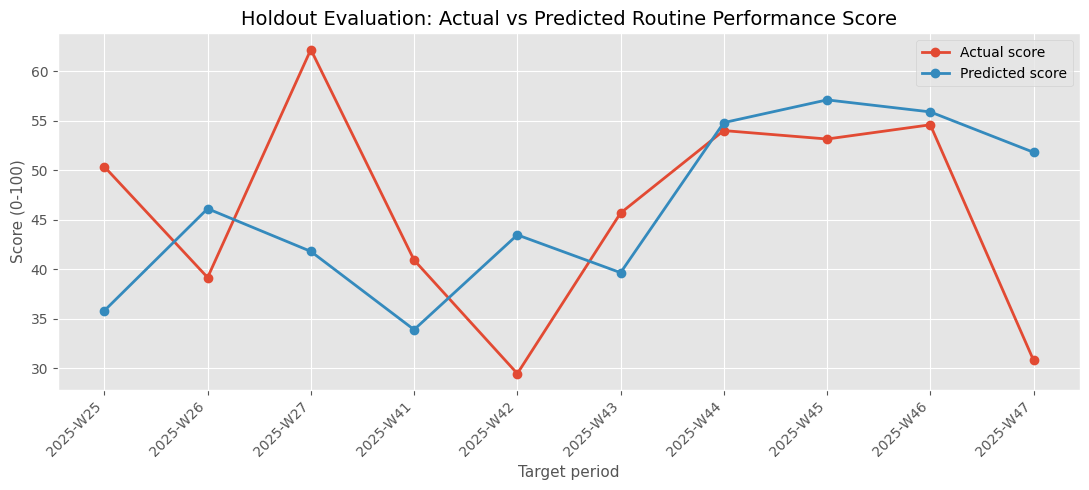

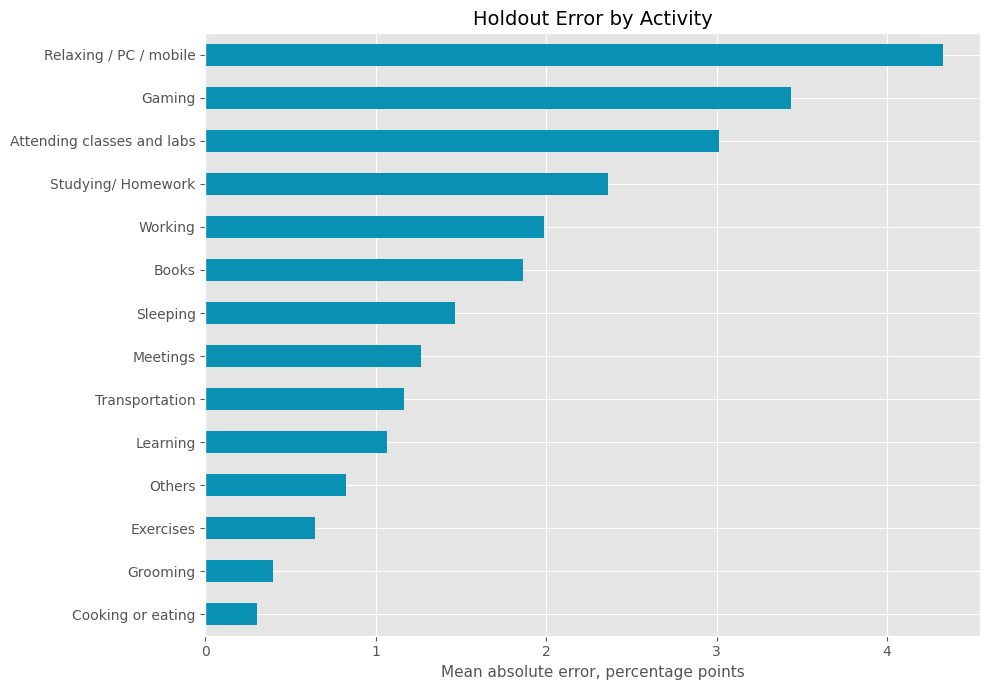

In [26]:
test_periods = pairs_test["target_period"].to_numpy()
test_positions = np.arange(len(test_periods))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_positions, y_test[:, SCORE_TARGET_IDX], marker="o", linewidth=2, label="Actual score")
ax.plot(test_positions, ridge_test_pred[:, SCORE_TARGET_IDX], marker="o", linewidth=2, label="Predicted score")
ax.set_title("Holdout Evaluation: Actual vs Predicted Routine Performance Score")
ax.set_xlabel("Target period")
ax.set_ylabel("Score (0-100)")
ax.set_xticks(test_positions)
ax.set_xticklabels(test_periods, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

activity_abs_error = pd.Series(
    np.abs(y_test[:, ACTIVITY_TARGET_IDX] - ridge_test_pred[:, ACTIVITY_TARGET_IDX]).mean(axis=0),
    index=activity_cols,
).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
activity_abs_error.plot(kind="barh", ax=ax, color="#0891b2")
ax.set_title("Holdout Error by Activity")
ax.set_xlabel("Mean absolute error, percentage points")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 7. Predict Next Week From This Week's Percentages

This section uses the `current_week_record_percentages` dictionary from the first code cell. The Excel workbook is the training history; the current-week percentages are the live input used for prediction.

In [27]:
final_model = fit_ridge_regression(X, y, alpha=best_alpha)


def activity_series_from_input(activity_values):
    unknown = sorted(set(activity_values) - set(activity_cols))
    if unknown:
        raise ValueError(f"Unknown activity names: {unknown}")

    series = pd.Series(0.0, index=activity_cols, dtype=float)
    for activity, value in activity_values.items():
        series[activity] = float(value)

    if (series < 0).any():
        negative_cols = series[series < 0].index.tolist()
        raise ValueError(f"Negative values are not allowed: {negative_cols}")

    return series


def record_to_activity_percentages(activity_record, mode="hours", total_hours=168):
    record = activity_series_from_input(activity_record)

    if mode == "hours":
        tracked_hours = record.sum()
        if tracked_hours > total_hours + 1e-6:
            raise ValueError(f"Tracked hours are {tracked_hours:.2f}, which is more than {total_hours}.")

        percentages = record / total_hours * 100
        untracked_hours = total_hours - tracked_hours
        if untracked_hours > 1e-6:
            percentages["Others"] += untracked_hours / total_hours * 100

    elif mode == "percent":
        percentages = record.copy()
        total = percentages.sum()
        if total > 100.5:
            raise ValueError(f"Input percentages add up to {total:.2f}%, which is above 100%.")
        if total < 99.5:
            percentages["Others"] += 100 - total
        else:
            percentages = percentages / total * 100

    else:
        raise ValueError("mode must be either 'hours' or 'percent'.")

    return percentages


def build_feature_row_from_activity_percentages(activity_percentages, current_year, current_week_num):
    current = pd.Series(activity_percentages, dtype=float).reindex(activity_cols).fillna(0.0)
    total = current.sum()
    if total <= 0:
        raise ValueError("Activity percentages must sum to a positive value.")
    current = current / total * 100

    current_frame = pd.DataFrame([current])
    current_frame["year"] = int(current_year)
    current_frame["week_num"] = int(current_week_num)
    current_features = add_behavior_features(current_frame)
    return current_features[FEATURE_COLS].to_numpy(dtype=float)


def predict_next_week_from_activity_percentages(activity_percentages, current_year, current_week_num):
    X_current = build_feature_row_from_activity_percentages(activity_percentages, current_year, current_week_num)
    prediction = predict_ridge_regression(final_model, X_current)
    prediction = postprocess_predictions(prediction)[0]
    return pd.Series(prediction, index=TARGET_COLS)


run_date = pd.Timestamp.today().normalize()
current_year = int(run_date.year)
current_week_num = int(run_date.isocalendar().week)
current_week_activity_percentages = record_to_activity_percentages(
    current_week_record_percentages,
    mode=CURRENT_RECORD_MODE,
)
current_week = current_week_activity_percentages
next_week_forecast = predict_next_week_from_activity_percentages(
    current_week_activity_percentages,
    current_year,
    current_week_num,
)

forecast_table = pd.DataFrame(
    {
        "current_week_record_%": current_week_activity_percentages,
        "predicted_next_week_%": next_week_forecast[activity_cols],
        "change_pp": next_week_forecast[activity_cols] - current_week_activity_percentages,
    }
).sort_values("predicted_next_week_%", ascending=False)

display(forecast_table.round(2))
print(f"Prediction source: current-week percentages entered on {run_date.date()} ({current_year}, ISO week {current_week_num})")
print(f"Input percentage total before normalization: {activity_series_from_input(current_week_record_percentages).sum():.2f}%")
print(f"Predicted next-week Routine Performance Score: {next_week_forecast['performance_score']:.1f} / 100")

,current_week_record_%,predicted_next_week_%,change_pp
Sleeping,25.15,25.82,0.68
Relaxing / PC / mobile,26.04,21.80,-4.24
Gaming,9.97,8.85,-1.12
Studying/ Homework,17.71,8.36,-9.35
Working,6.10,6.48,0.39
Attending classes and labs,2.98,4.90,1.92
Cooking or eating,2.98,3.77,0.79
Others,1.79,3.58,1.79
Meetings,0.89,3.14,2.25
Books,0.89,3.08,2.19


Prediction source: current-week percentages entered on 2026-05-28 (2026, ISO week 22)
Input percentage total before normalization: 100.01%
Predicted next-week Routine Performance Score: 54.2 / 100


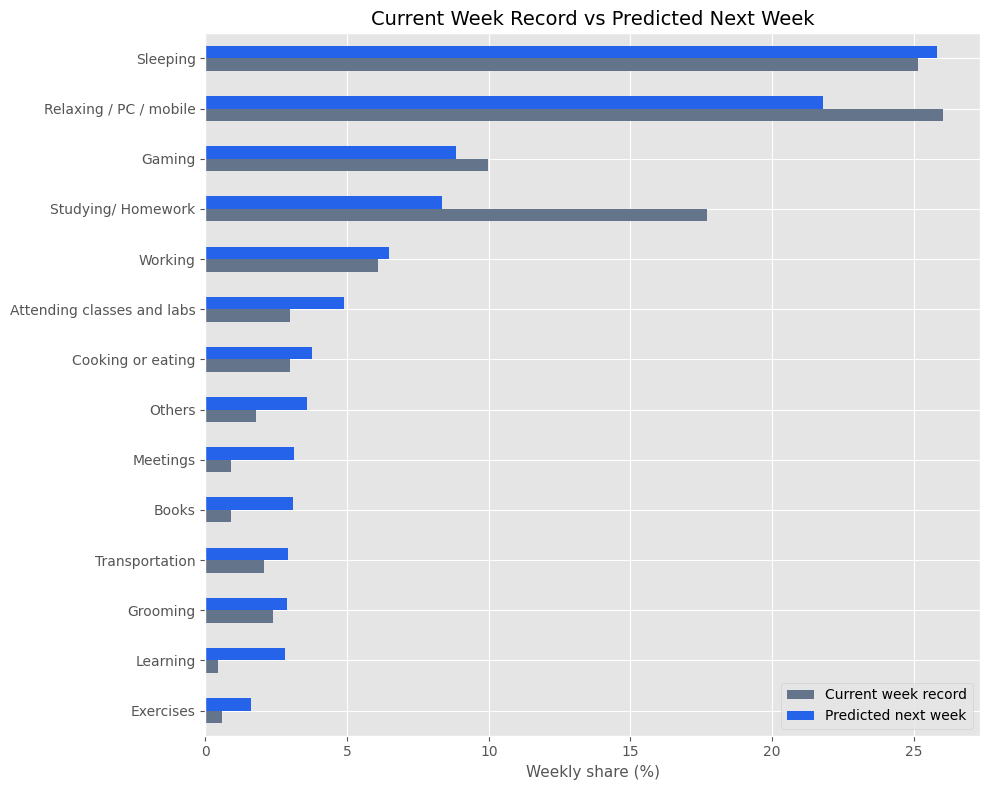

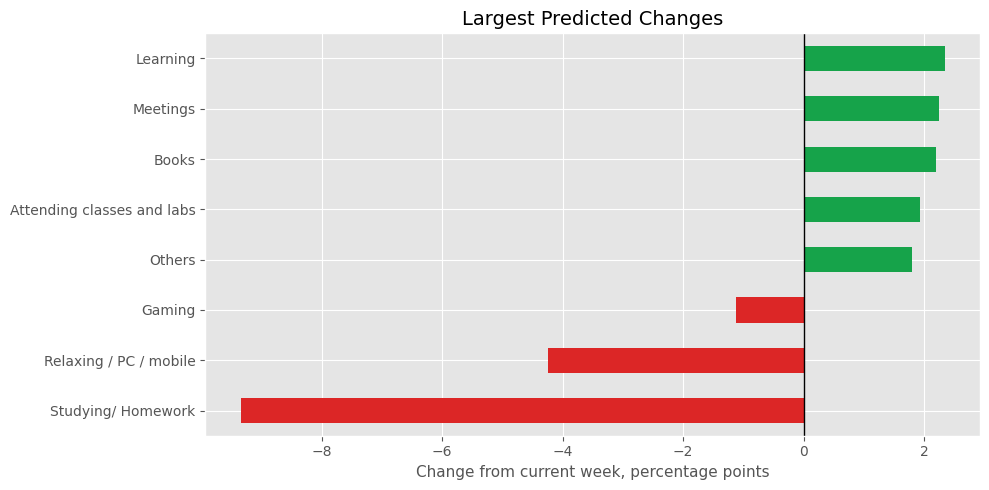

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
forecast_table[["current_week_record_%", "predicted_next_week_%"]].sort_values("predicted_next_week_%").plot(
    kind="barh",
    ax=ax,
    color=["#64748b", "#2563eb"],
)
ax.set_title("Current Week Record vs Predicted Next Week")
ax.set_xlabel("Weekly share (%)")
ax.set_ylabel("")
ax.legend(["Current week record", "Predicted next week"])
plt.tight_layout()
plt.show()

top_changes = forecast_table.reindex(forecast_table["change_pp"].abs().sort_values(ascending=False).index).head(8)

fig, ax = plt.subplots(figsize=(10, 5))
top_changes["change_pp"].sort_values().plot(
    kind="barh",
    ax=ax,
    color=["#dc2626" if value < 0 else "#16a34a" for value in top_changes["change_pp"].sort_values()],
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Largest Predicted Changes")
ax.set_xlabel("Change from current week, percentage points")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. What-If Forecasting With This Week's Percentages

Use this cell to test a different version of this week's percentages. For example, you can increase studying or reduce gaming and see how the next-week performance forecast changes.

In [29]:
custom_current_week_record_percentages = current_week_record_percentages.copy()

# Example scenario:
# custom_current_week_record_percentages["Studying/ Homework"] += 3
# custom_current_week_record_percentages["Gaming"] = max(0, custom_current_week_record_percentages["Gaming"] - 3)

custom_current_week_percentages = record_to_activity_percentages(
    custom_current_week_record_percentages,
    mode=CURRENT_RECORD_MODE,
)
custom_forecast = predict_next_week_from_activity_percentages(
    custom_current_week_percentages,
    current_year,
    current_week_num,
)

custom_forecast_table = pd.DataFrame(
    {
        "custom_current_week_record_%": custom_current_week_percentages,
        "custom_predicted_next_week_%": custom_forecast[activity_cols],
        "change_pp": custom_forecast[activity_cols] - custom_current_week_percentages,
    }
).sort_values("custom_predicted_next_week_%", ascending=False)

display(custom_forecast_table.round(2))
print(f"Custom scenario predicted score: {custom_forecast['performance_score']:.1f} / 100")

,custom_current_week_record_%,custom_predicted_next_week_%,change_pp
Sleeping,25.15,25.82,0.68
Relaxing / PC / mobile,26.04,21.80,-4.24
Gaming,9.97,8.85,-1.12
Studying/ Homework,17.71,8.36,-9.35
Working,6.10,6.48,0.39
Attending classes and labs,2.98,4.90,1.92
Cooking or eating,2.98,3.77,0.79
Others,1.79,3.58,1.79
Meetings,0.89,3.14,2.25
Books,0.89,3.08,2.19


Custom scenario predicted score: 54.2 / 100


## 9. Forecast Notes

These notes turn the prediction into a short interpretation. They are rule-based on top of the model output, so they remain easy to inspect and edit.

In [30]:
def series_sum(series, columns):
    existing = [col for col in columns if col in series.index]
    if not existing:
        return 0.0
    return float(series[existing].sum())


def generate_forecast_notes(current, forecast, historical):
    forecast_activity = forecast[activity_cols]

    current_focus = series_sum(current, ACADEMIC_COLS)
    forecast_focus = series_sum(forecast_activity, ACADEMIC_COLS)
    forecast_leisure = series_sum(forecast_activity, LEISURE_COLS)
    forecast_sleep = float(forecast_activity["Sleeping"])
    score = float(forecast["performance_score"])

    historical_focus_median = float(historical["academic_focus"].median())
    historical_leisure_q75 = float(historical["screen_leisure"].quantile(0.75))

    change = forecast_activity - current
    biggest_increase = change.idxmax()
    biggest_decrease = change.idxmin()

    rows = []

    rows.append(
        {
            "signal": "Predicted score",
            "forecast_note": f"{score:.1f}/100 based on this week's activity record and your 2024-2025 history.",
        }
    )

    if forecast_focus < historical_focus_median:
        rows.append(
            {
                "signal": "Academic focus",
                "forecast_note": (
                    f"Predicted academic focus is {forecast_focus:.1f}%, below your 2024-2025 median of "
                    f"{historical_focus_median:.1f}%."
                ),
            }
        )
    else:
        rows.append(
            {
                "signal": "Academic focus",
                "forecast_note": (
                    f"Predicted academic focus is {forecast_focus:.1f}%, at or above your 2024-2025 median."
                ),
            }
        )

    if forecast_leisure > historical_leisure_q75:
        rows.append(
            {
                "signal": "Leisure pressure",
                "forecast_note": (
                    f"Gaming plus relaxing/mobile is forecast at {forecast_leisure:.1f}%, above your upper-quartile level."
                ),
            }
        )
    else:
        rows.append(
            {
                "signal": "Leisure pressure",
                "forecast_note": f"Leisure load is forecast at {forecast_leisure:.1f}%, within your normal range.",
            }
        )

    rows.append(
        {
            "signal": "Sleep balance",
            "forecast_note": f"Sleeping is forecast at {forecast_sleep:.1f}% of the week; ideal 8 hours/day is about 33.3%.",
        }
    )

    rows.append(
        {
            "signal": "Largest increase",
            "forecast_note": f"{biggest_increase}: {change[biggest_increase]:+.2f} percentage points.",
        }
    )

    rows.append(
        {
            "signal": "Largest decrease",
            "forecast_note": f"{biggest_decrease}: {change[biggest_decrease]:+.2f} percentage points.",
        }
    )

    return pd.DataFrame(rows)


forecast_notes = generate_forecast_notes(current_week, next_week_forecast, weekly_model)
display(forecast_notes)

,signal,forecast_note
0,Predicted score,54.2/100 based on this week's activity record ...
1,Academic focus,"Predicted academic focus is 19.1%, at or above..."
2,Leisure pressure,"Leisure load is forecast at 30.6%, within your..."
3,Sleep balance,Sleeping is forecast at 25.8% of the week; ide...
4,Largest increase,Learning: +2.34 percentage points.
5,Largest decrease,Studying/ Homework: -9.35 percentage points.
